In [1]:
  !pip install pandas numpy scikit-learn seaborn matplotlib

In [2]:
from numpy.random.mtrand import rand
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import (make_classification, make_regression, load_breast_cancer, load_diabetes)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC


from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score,roc_auc_score, roc_curve, precision_recall_curve,
                             confusion_matrix, classification_report, mean_squared_error, mean_absolute_error,r2_score,ConfusionMatrixDisplay)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)
print("all libraries imported")
print(f"Numpy:{np.__version__} | Pandas:{pd.__version__}")

all libraries imported
Numpy:2.0.2 | Pandas:2.2.2


In [3]:
# Dataset preparation

# Classification: Breast Cancer Dataset

cancer = load_breast_cancer()

X_clf, y_clf = cancer.data, cancer.target # 0=malignant, 1=benign

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf,

test_size=0.2, random_state=42)

# Feature scaling - important for Logistic Regression and SVM

scaler_c = StandardScaler()

X_train_c = scaler_c.fit_transform(X_train_c)

X_test_c = scaler_c.transform(X_test_c)

# Diabaetes dataset

diabetes = load_diabetes()

X_reg, y_reg = diabetes.data, diabetes.target

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(

 X_reg, y_reg, test_size=0.2, random_state=42)

scaler_r = StandardScaler()

X_train_r = scaler_r.fit_transform(X_train_r)
X_test_r = scaler_r.transform(X_test_r)
#---Quick data summary---

print("CLASSIFICATION DATASER (Breast Cancer)")

print(f" Train: (X_train_c.shape) | Test: (X_test_c.shape)")

print(f" Class balance - Malignant: {(y_clf==0).sum()} | Benign: {(y_clf==1).sum()}\n")

print("REGRESSION DATASET (Diabetes)")

print(f" Train: {X_train_r.shape} | Test: {X_test_r.shape}")

print(f" Target range: [{y_reg.min():.0f}, {y_reg.max():.0f}]")


CLASSIFICATION DATASER (Breast Cancer)
 Train: (X_train_c.shape) | Test: (X_test_c.shape)
 Class balance - Malignant: 212 | Benign: 357

REGRESSION DATASET (Diabetes)
 Train: (353, 10) | Test: (89, 10)
 Target range: [25, 346]


Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']
Class imbalance ratio: 0.59


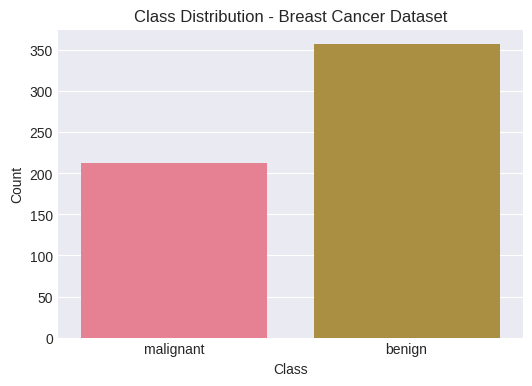

In [4]:
# STUDENT TASKS
#1. Print the feature names of breast cancer dataset
# 2. Caldulate and print class imbalance ratio (malignant/benign)
# 3. Plot a bar chart showing class distribution

#TODO: Print first 5 feature names

print("Feature names:", cancer.feature_names[:5])

#TODO: Calculate imbalance ratio
# 2. Calculate and print class imbalance ratio (malignant/benign)
# Note: From the setup cell, y_clf == 0 is malignant and y_clf == 1 is benign
malignant_count = (y_clf == 0).sum()
benign_count = (y_clf == 1).sum()

imbalance_ratio = malignant_count / benign_count

print(f"Class imbalance ratio: {imbalance_ratio:.2f}")

# TODO: Plot class distribution

plt.figure(figsize=(6, 4))

# your code here
sns.countplot(x=y_clf, hue=y_clf, legend=False)
plt.xticks(ticks=[0, 1], labels=cancer.target_names)
plt.xlabel("Class")
plt.ylabel("Count")

plt.title("Class Distribution - Breast Cancer Dataset")

plt.show()


(name): Accuracy = [results[name]['accuracy']:4f)
(name): Accuracy = [results[name]['accuracy']:4f)
(name): Accuracy = [results[name]['accuracy']:4f)


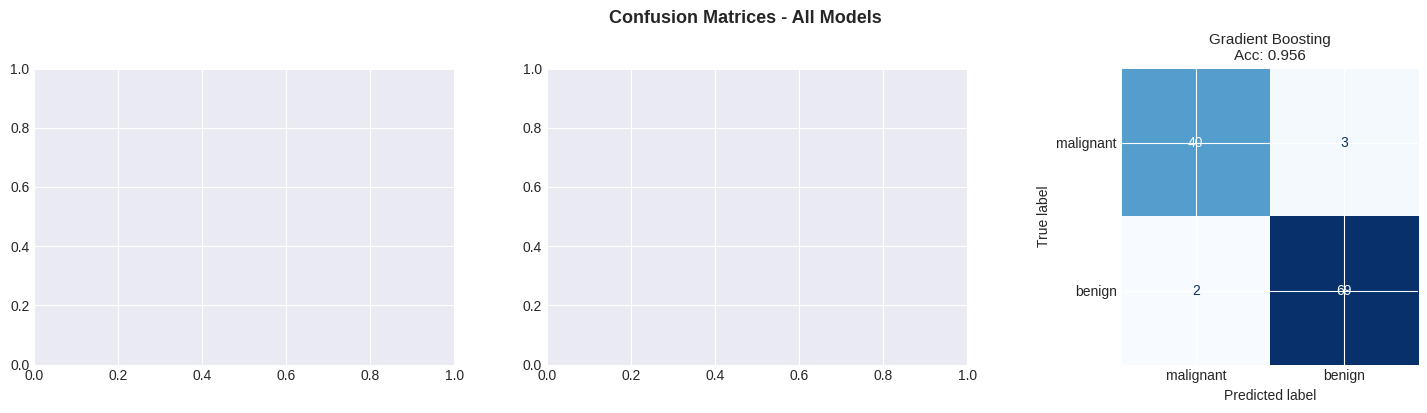

In [5]:
# Accuracy and Confusion Matrix

# Train three classifiers for comparison

models = {

'Logistic Regression': LogisticRegression(max_iter=1000),

'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),

'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)

}

results = {}

for name, model in models.items():

    model.fit(X_train_c, y_train_c)

    y_pred= model.predict(X_test_c)

    y_proba = model.predict_proba(X_test_c)[:, 1]

    results[name] = {


      'model': model,

      'y_pred': y_pred,

      'y_proba': y_proba,

      'accuracy': accuracy_score(y_test_c, y_pred),

      'cm': confusion_matrix(y_test_c, y_pred)
    }

    print(f"(name): Accuracy = [results[name]['accuracy']:4f)")

#-Visualise confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, (name, res) in zip(axes, results.items()):

    disp = ConfusionMatrixDisplay(confusion_matrix=res['cm'],
display_labels=cancer.target_names
)

disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f"{name}\nAcc: {res['accuracy']:.3f}", fontsize=11)

plt.tight_layout()

plt.suptitle("Confusion Matrices - All Models", y=1.02, fontsize=13, fontweight='bold')
plt.show()

In [6]:
#STUDENT TASK 2 Confusion Matrix Deep Dive

# Instructions:# 1.

#Pick the Logistic Regression model's confusion matrix
# 2. Extract TP, FP, TN, FN values manually
# 3. Calculate accuracy from scratch (without sklearn) and verify it matches
## Recall: sklearn's confusion_matrix returns:
# [[TN, FP],# [FN, TP]]

# 1. Pick the Logistic Regression model's confusion matrix from the results dictionary
cm_lr = results['Logistic Regression']['cm']

# 2. Extract TN, FP, FN, TP values manually
# Based on the recall note:
# [[TN, FP],
#  [FN, TP]]
tn = cm_lr[0, 0]
fp = cm_lr[0, 1]
fn = cm_lr[1, 0]
tp = cm_lr[1, 1]

print("--- Manually Extracted Values ---")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}\n")

# 3. Calculate accuracy from scratch (without sklearn)
total_predictions = tp + tn + fp + fn
accuracy_scratch = (tp + tn) / total_predictions

# Fetch the sklearn accuracy stored from the previous cell to verify
accuracy_sklearn = results['Logistic Regression']['accuracy']

print("--- Verification ---")
print(f"Accuracy calculated from scratch: {accuracy_scratch:.4f}")
print(f"Accuracy from scikit-learn:       {accuracy_sklearn:.4f}")
print(f"Do the accuracy values match?     {np.isclose(accuracy_scratch, accuracy_sklearn)}")

--- Manually Extracted Values ---
True Negatives (TN):  41
False Positives (FP): 2
False Negatives (FN): 1
True Positives (TP):  70

--- Verification ---
Accuracy calculated from scratch: 0.9737
Accuracy from scikit-learn:       0.9737
Do the accuracy values match?     True


In [7]:
# Day 1 Coding Activity - Sentiment Analysis with Hugging Face

# EY Workshop | Participant: Likhitha


from transformers import pipeline

# TODO 1: Initialise a sentiment-analysis pipeline

# Hint: classifier = pipeline("sentiment-analysis")

classifier = pipeline("sentiment-analysis")

# Sample sentences relevant to consulting work

sentences = [

"The client was very satisfied with the delivery.",

"The project is significantly over budget and behind schedule.",

"The new regulatory framework presents both risks and opportunities."

] # TODO 2: Add ONE sentence of your own make it work-relevant

# TODO 3: Run the classifier on all sentences and print results

# Expected output format:

# "The client was satisfied..." POSITIVE (0.9987)

for sentence in sentences:

    result = classifier(sentence)

    label = result[0]['label']

    score = result[0]['score']

print(f'"{sentence[:50]}..." → {label} ({score:.4f})')

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

"The new regulatory framework presents both risks a..." → POSITIVE (0.9911)
